## Modèle SIRD (Susceptible, Infecté, Remis, Mort)

![Modéle SIRD.png](<attachment:Modéle SIRD.png>)

$$\frac{dS}{dt} = - \beta IS$$
$$\frac{dI}{dt} = \beta IS - \gamma I - \mu I$$
$$\frac{dR}{dt} = \gamma I$$
$$\frac{dD}{dt} = \mu I$$

* $N$ : Nombre de personnes dans la simulation
* $\beta$ : Coefficient d'infection
* $\gamma$ : Coefficient de guérison
* $\mu$ : Coefficient de mortalité
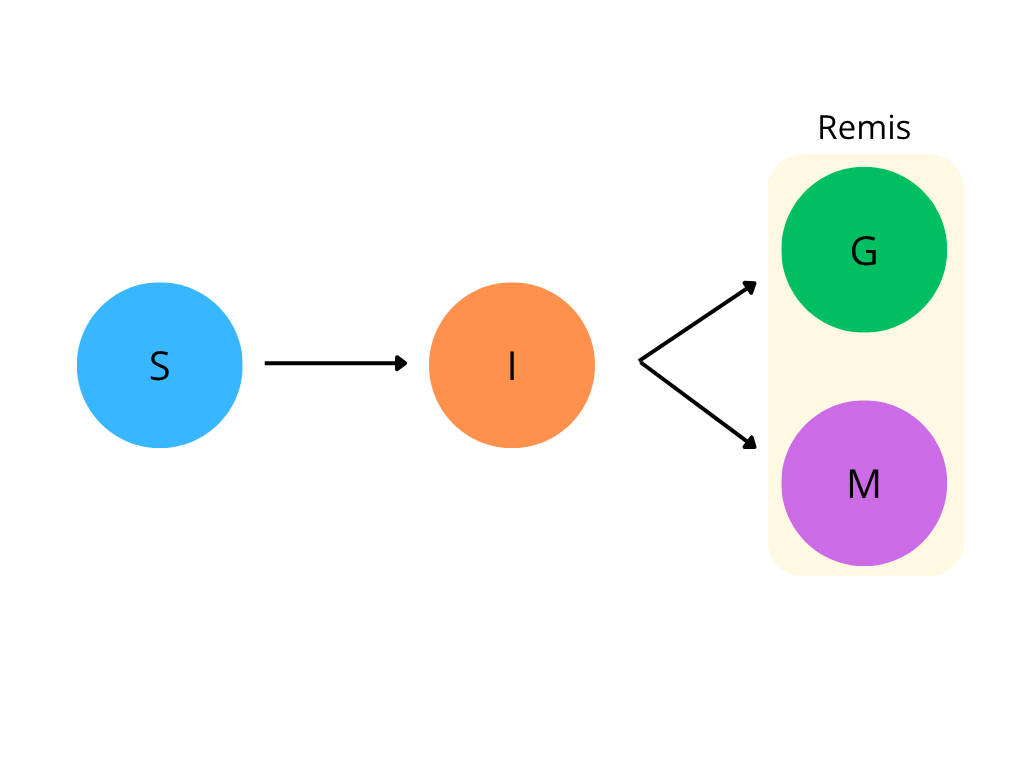

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nosPackages.mathUtils as mathUtils

# population initial
S_init=0.999 # personnes suscétibles (départ) en fraction -> 1=100%
I_init=0.001 # personnes infectés
R_init=0 # personnes guérissent
D_init=0 # personnes qui meurent

# paramètre de contagion
beta=0.558 # taux de contagion journalier de base pour le covid = 0.6 personnes/jour
gamma=0.2 # 1/gamma = nb de jour contagieux = 5 jour pour le covid
mu= 0.01 # Coefficient de décès (valeur non réelle)
R0=beta/gamma*S_init # nombre de personnes contaminés par un malade = 3 pour le covid

In [8]:
dt = 0.1
tmax = 100.0
temps = np.arange(0, tmax + dt, dt)
n = temps.size

S = np.empty(n)
I = np.empty(n)
R = np.empty(n)
D = np.empty(n)
Rt = np.empty(n)

y = np.empty(4)
y[0] = S_init
y[1] = I_init
y[2] = R_init
y[3] = D_init

params={"beta":beta,"gamma":gamma, "mu":mu}
model=mathUtils.SIR(params)
deriv=model.deriv_SIRD
euler=model.euler

for i in range(n):
    S[i] = y[0]
    I[i] = y[1]
    R[i] = y[2]
    D[i] = y[3]
    t = temps[i]
    y = euler(t, dt, y, deriv)
Rt = R0*S # evolution du R0 (contagion pour une personne)

In [9]:
"""plt.figure()
plt.title("Evolution de S(t)")
plt.plot(temps, S)
plt.xlabel("temps")
plt.ylabel("S(t)")
plt.savefig("sird_S.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de I(t)")
plt.plot(temps, I)
plt.xlabel("temps")
plt.ylabel("I(t)")
plt.savefig("sird_I.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de R(t)")
plt.plot(temps, R)
plt.xlabel("temps")
plt.ylabel("R(t)")
plt.savefig("sird_R.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de D(t)")
plt.plot(temps, D)
plt.xlabel("temps")
plt.ylabel("D(t)")
plt.savefig("sird_R.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de Rt")
plt.plot(temps, Rt)
plt.xlabel("temps")
plt.ylabel("Rt")
plt.savefig("sird_Rt.pdf", bbox_inches='tight')
plt.show()
"""

'plt.figure()\nplt.title("Evolution de S(t)")\nplt.plot(temps, S)\nplt.xlabel("temps")\nplt.ylabel("S(t)")\nplt.savefig("sird_S.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de I(t)")\nplt.plot(temps, I)\nplt.xlabel("temps")\nplt.ylabel("I(t)")\nplt.savefig("sird_I.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de R(t)")\nplt.plot(temps, R)\nplt.xlabel("temps")\nplt.ylabel("R(t)")\nplt.savefig("sird_R.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de D(t)")\nplt.plot(temps, D)\nplt.xlabel("temps")\nplt.ylabel("D(t)")\nplt.savefig("sird_R.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de Rt")\nplt.plot(temps, Rt)\nplt.xlabel("temps")\nplt.ylabel("Rt")\nplt.savefig("sird_Rt.pdf", bbox_inches=\'tight\')\nplt.show()\n'

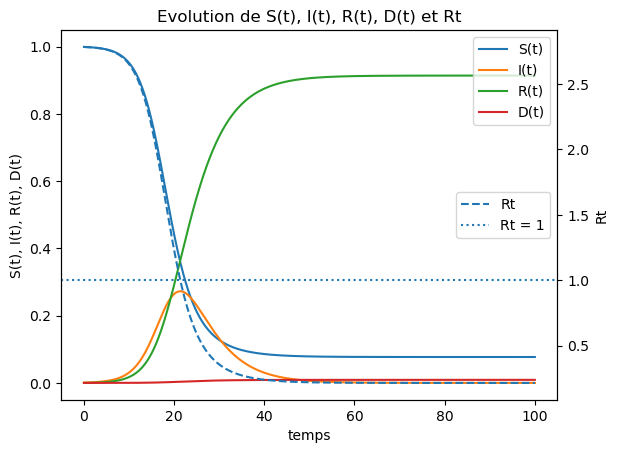

In [10]:
plt.figure()
plt.title("Evolution de S(t), I(t), R(t), D(t) et Rt")

ax1 = plt.gca()
ax1.plot(temps, S, label="S(t)")
ax1.plot(temps, I, label="I(t)")
ax1.plot(temps, R, label="R(t)")
ax1.plot(temps, D, label="D(t)")
ax1.set_xlabel("temps")
ax1.set_ylabel("S(t), I(t), R(t), D(t)")
ax1.legend(loc="upper right")

ax2 = ax1.twinx()
ax2.plot(temps, Rt, "--", label="Rt")
ax2.axhline(1, linestyle=":", label="Rt = 1")
ax2.set_ylabel("Rt")
ax2.legend(loc="center right")

plt.savefig("sir_SIRD_Rt.pdf", bbox_inches='tight')
plt.show()

## Modèle SIRD développé

![Modèle SIRDV.png](<attachment:Modèle SIRDV.png>)
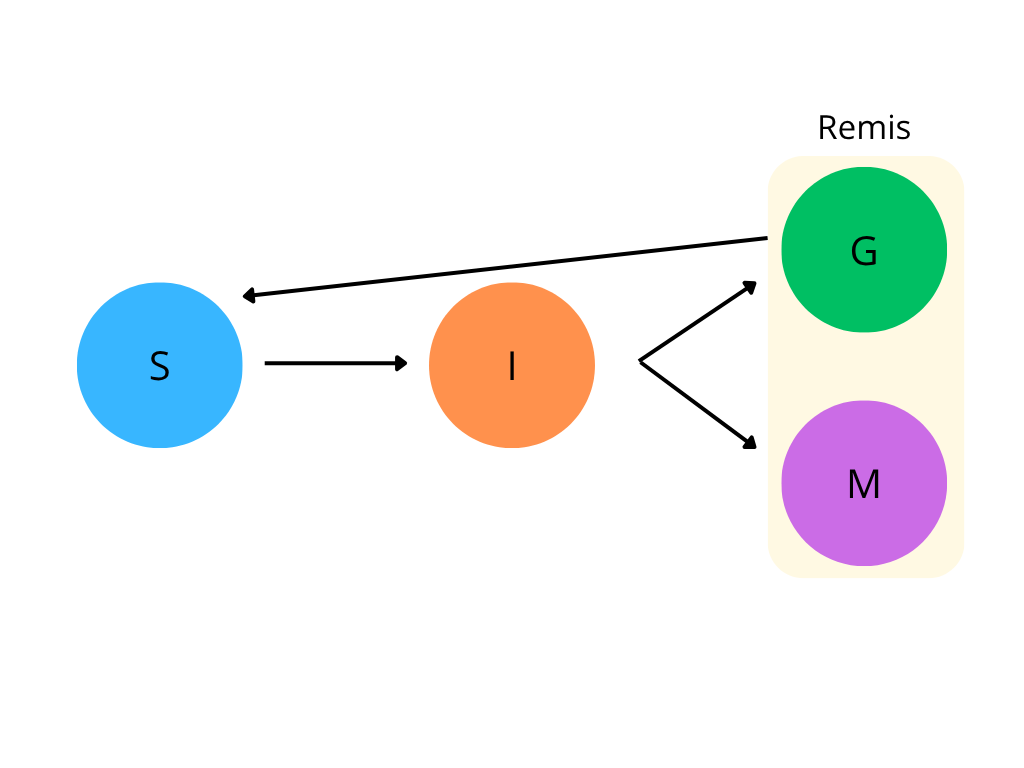

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nosPackages.mathUtils as mathUtils

# population initial
S_init=0.999 # personnes suscétibles (départ) en fraction -> 1=100%
I_init=0.001 # personnes infectés
R_init=0 # personnes guérissent
D_init=0 # personnes qui meurent

# paramètre de contagion
beta=0.558 # taux de contagion journalier de base pour le covid = 0.6 personnes/jour
gamma=0.2 # 1/gamma = nb de jour contagieux = 5 jour pour le covid
mu= 0.01 # Coefficient de décès (valeur non réelle)
rho = 0.04 # Taux de perte d'immunité (25 jours)
R0=beta/gamma*S_init # nombre de personnes contaminés par un malade = 3 pour le covid

In [2]:
dt = 0.1
tmax = 100.0
temps = np.arange(0, tmax + dt, dt)
n = temps.size

S = np.empty(n)
I = np.empty(n)
R = np.empty(n)
D = np.empty(n)
Rt = np.empty(n)

y = np.empty(4)
y[0] = S_init
y[1] = I_init
y[2] = R_init
y[3] = D_init

params={"beta":beta,"gamma":gamma, "mu":mu, "rho":rho}
model=mathUtils.SIR(params)
deriv=model.deriv_SIRD_dev
euler=model.euler

for i in range(n):
    S[i] = y[0]
    I[i] = y[1]
    R[i] = y[2]
    D[i] = y[3]
    t = temps[i]
    y = euler(t, dt, y, deriv)
Rt = R0*S # evolution du R0 (contagion pour une personne)

NameError: name 'rho' is not defined

In [ ]:
"""plt.figure()
plt.title("Evolution de S(t)")
plt.plot(temps, S)
plt.xlabel("temps")
plt.ylabel("S(t)")
plt.savefig("sird_S.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de I(t)")
plt.plot(temps, I)
plt.xlabel("temps")
plt.ylabel("I(t)")
plt.savefig("sird_I.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de R(t)")
plt.plot(temps, R)
plt.xlabel("temps")
plt.ylabel("R(t)")
plt.savefig("sird_R.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de D(t)")
plt.plot(temps, D)
plt.xlabel("temps")
plt.ylabel("D(t)")
plt.savefig("sird_R.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de Rt")
plt.plot(temps, Rt)
plt.xlabel("temps")
plt.ylabel("Rt")
plt.savefig("sird_Rt.pdf", bbox_inches='tight')
plt.show()
"""

In [ ]:
plt.figure()
plt.title("Evolution de S(t), I(t), R(t), D(t) et Rt")

ax1 = plt.gca()
ax1.plot(temps, S, label="S(t)")
ax1.plot(temps, I, label="I(t)")
ax1.plot(temps, R, label="R(t)")
ax1.plot(temps, D, label="D(t)")
ax1.set_xlabel("temps")
ax1.set_ylabel("S(t), I(t), R(t), D(t)")
ax1.legend(loc="upper right")

ax2 = ax1.twinx()
ax2.plot(temps, Rt, "--", label="Rt")
ax2.axhline(1, linestyle=":", label="Rt = 1")
ax2.set_ylabel("Rt")
ax2.legend(loc="center right")

plt.savefig("sir_SIRD_Rt.pdf", bbox_inches='tight')
plt.show()

## Modèle SIRDV (Susceptible, Infecté, Remis, Mort, Vacciné)

![Modèle SIRD dev.png](<attachment:Modèle SIRD dev.png>)

$$\frac{dS}{dt} = - \beta IS - \omega S$$
$$\frac{dI}{dt} = \beta IS - \gamma I - \mu I$$
$$\frac{dR}{dt} = \gamma I$$
$$\frac{dD}{dt} = \mu I$$
$$\frac{dV}{dt} = \omega S$$

* $N$ : Nombre de personnes dans la simulation
* $\beta$ : Coefficient d'infection
* $\gamma$ : Coefficient de guérison
* $\mu$ : Coefficient de mortalité
* $\omega$ : Coefficient de vaccination
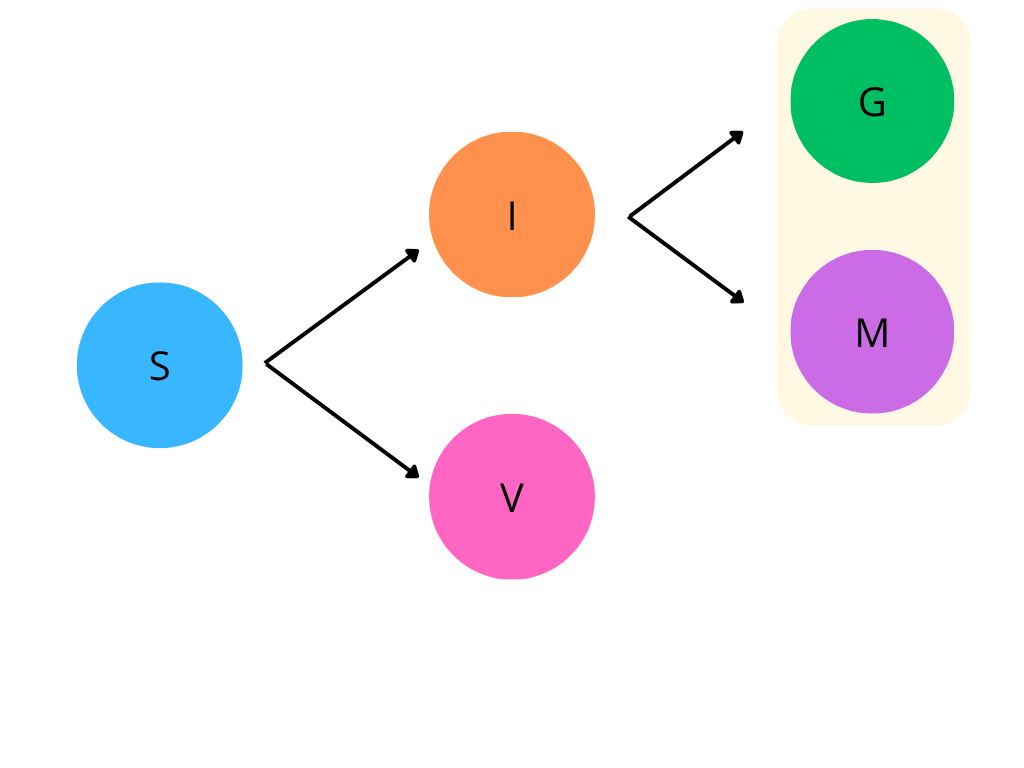

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nosPackages.mathUtils as mathUtils

# population initial
S_init=0.999 # personnes suscétibles (départ) en fraction -> 1=100%
I_init=0.001 # personnes infectés
R_init=0 # personnes guérissent
D_init=0 # personnes qui meurent
V_init=0 # personnes vaccinées

# paramètre de contagion
beta=0.558 # taux de contagion journalier de base pour le covid = 0.6 personnes/jour
gamma=0.2 # 1/gamma = nb de jour contagieux = 5 jour pour le covid
mu= 0.002 # Coefficient de décès (valeur non réelle)
omega= 0.01 # Taux de personnes vaccinées
R0=beta/(gamma)*S_init # nombre de personnes contaminés par un malade = 3 pour le covid

In [6]:
dt = 0.1
tmax = 100.0
temps = np.arange(0, tmax + dt, dt)
n = temps.size

S = np.empty(n)
I = np.empty(n)
R = np.empty(n)
D = np.empty(n)
V = np.empty(n)
Rt = np.empty(n)

y = np.empty(5)
y[0] = S_init
y[1] = I_init
y[2] = R_init
y[3] = D_init
y[4] = V_init

params={"beta":beta, "gamma":gamma, "mu":mu, "omega":omega}
model=mathUtils.SIR(params)
deriv=model.deriv_SIRDV
euler=model.euler

for i in range(n):
    S[i] = y[0]
    I[i] = y[1]
    R[i] = y[2]
    D[i] = y[3]
    V[i] = y[4]
    t = temps[i]
    y = euler(t, dt, y, deriv)
Rt = R0*S # evolution du R0 (contagion pour une personne)

In [3]:
"""plt.figure()
plt.title("Evolution de S(t)")
plt.plot(temps, S)
plt.xlabel("temps")
plt.ylabel("S(t)")
plt.savefig("sird_S.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de I(t)")
plt.plot(temps, I)
plt.xlabel("temps")
plt.ylabel("I(t)")
plt.savefig("sird_I.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de R(t)")
plt.plot(temps, R)
plt.xlabel("temps")
plt.ylabel("R(t)")
plt.savefig("sird_R.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de D(t)")
plt.plot(temps, D)
plt.xlabel("temps")
plt.ylabel("D(t)")
plt.savefig("sird_R.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de V(t)")
plt.plot(temps, V)
plt.xlabel("temps")
plt.ylabel("V(t)")
plt.savefig("sird_R.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de Rt")
plt.plot(temps, Rt)
plt.xlabel("temps")
plt.ylabel("Rt")
plt.savefig("sird_Rt.pdf", bbox_inches='tight')
plt.show()
"""

'plt.figure()\nplt.title("Evolution de S(t)")\nplt.plot(temps, S)\nplt.xlabel("temps")\nplt.ylabel("S(t)")\nplt.savefig("sird_S.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de I(t)")\nplt.plot(temps, I)\nplt.xlabel("temps")\nplt.ylabel("I(t)")\nplt.savefig("sird_I.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de R(t)")\nplt.plot(temps, R)\nplt.xlabel("temps")\nplt.ylabel("R(t)")\nplt.savefig("sird_R.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de D(t)")\nplt.plot(temps, D)\nplt.xlabel("temps")\nplt.ylabel("D(t)")\nplt.savefig("sird_R.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de V(t)")\nplt.plot(temps, V)\nplt.xlabel("temps")\nplt.ylabel("V(t)")\nplt.savefig("sird_R.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de Rt")\nplt.plot(temps, Rt)\nplt.xlabel("temps")\nplt.ylabel("Rt")\nplt.savefig("sird_Rt.pdf", bbox_inches=\

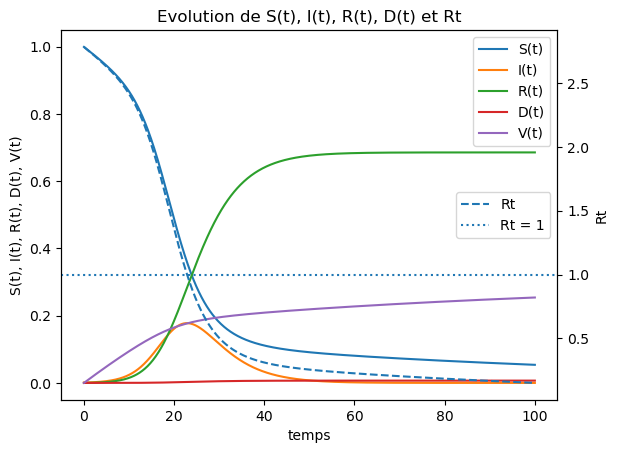

In [7]:
plt.figure()
plt.title("Evolution de S(t), I(t), R(t), D(t) et Rt")

ax1 = plt.gca()
ax1.plot(temps, S, label="S(t)")
ax1.plot(temps, I, label="I(t)")
ax1.plot(temps, R, label="R(t)")
ax1.plot(temps, D, label="D(t)")
ax1.plot(temps, V, label="V(t)")
ax1.set_xlabel("temps")
ax1.set_ylabel("S(t), I(t), R(t), D(t), V(t)")
ax1.legend(loc="upper right")

ax2 = ax1.twinx()
ax2.plot(temps, Rt, "--", label="Rt")
ax2.axhline(1, linestyle=":", label="Rt = 1")
ax2.set_ylabel("Rt")
ax2.legend(loc="center right")

plt.savefig("sir_SIRDV_Rt.pdf", bbox_inches='tight')
plt.show()